# **Simulación de eventos discretos con SimPy**

Instalar librería SimPy

In [1]:
!pip install simpy

Importar SimPy

In [2]:
import simpy

# Funciones generadoras para procesos de modelado

Ejemplo 1

In [3]:
def generator(x):
  y = yield x + 1 # ceder o producir
  return y + 1

In [4]:
g = generator(3)

In [5]:
next(g)

4

Ejemplo 2

In [6]:
def double_inputs():
  while True:
    x = yield
    yield x * 2

In [7]:
gen = double_inputs()

In [8]:
next(gen)       # correr hasta la primera cesión

In [9]:
gen.send(5)    # entra en la variable 'x'

10

In [10]:
next(gen)       # correr hasta la siguiente cesión

In [11]:
gen.send(6)     # entra en la variable 'x' de nuevo

12

In [12]:
next(gen)       # correr hasta la siguiente cesión

In [13]:
gen.send(94.3)  # entra en la variable 'x' de nuevo

188.6

# Ejemplo

In [14]:
def clock(env, name, tick):
  while True:
    print(name, env.now)
    yield env.timeout(tick)

In [15]:
env = simpy.Environment()

In [16]:
env.process(clock(env, 'rápido', 0.5))

<Process(clock) object at 0x7b88670d7b60>

In [17]:
env.process(clock(env, 'lento', 1))

<Process(clock) object at 0x7b886723aad0>

In [18]:
env.run(until=5)

rápido 0
lento 0
rápido 0.5
lento 1
rápido 1.0
rápido 1.5
lento 2
rápido 2.0
rápido 2.5
lento 3
rápido 3.0
rápido 3.5
lento 4
rápido 4.0
rápido 4.5


In [19]:
env = simpy.Environment()

In [20]:
env.process(clock(env, 'rápido', 0.5))

<Process(clock) object at 0x7b8866fd8190>

In [21]:
env.process(clock(env, 'lento', 1))

<Process(clock) object at 0x7b88670ce2c0>

In [22]:
env.process(clock(env, 'muy rápido', 0.01))

<Process(clock) object at 0x7b88670ce520>

In [23]:
env.run(until=5)

rápido 0
lento 0
muy rápido 0
muy rápido 0.01
muy rápido 0.02
muy rápido 0.03
muy rápido 0.04
muy rápido 0.05
muy rápido 0.060000000000000005
muy rápido 0.07
muy rápido 0.08
muy rápido 0.09
muy rápido 0.09999999999999999
muy rápido 0.10999999999999999
muy rápido 0.11999999999999998
muy rápido 0.12999999999999998
muy rápido 0.13999999999999999
muy rápido 0.15
muy rápido 0.16
muy rápido 0.17
muy rápido 0.18000000000000002
muy rápido 0.19000000000000003
muy rápido 0.20000000000000004
muy rápido 0.21000000000000005
muy rápido 0.22000000000000006
muy rápido 0.23000000000000007
muy rápido 0.24000000000000007
muy rápido 0.25000000000000006
muy rápido 0.26000000000000006
muy rápido 0.2700000000000001
muy rápido 0.2800000000000001
muy rápido 0.2900000000000001
muy rápido 0.3000000000000001
muy rápido 0.3100000000000001
muy rápido 0.3200000000000001
muy rápido 0.3300000000000001
muy rápido 0.34000000000000014
muy rápido 0.35000000000000014
muy rápido 0.36000000000000015
muy rápido 0.370000000000

# **Environment**<br>
simular “tan rápido como sea posible”



# **RealtimeEnvironment**<br>
sincronizado con el tiempo del reloj de pared

# Los eventos de tiempo de espera dejan pasar el tiempo

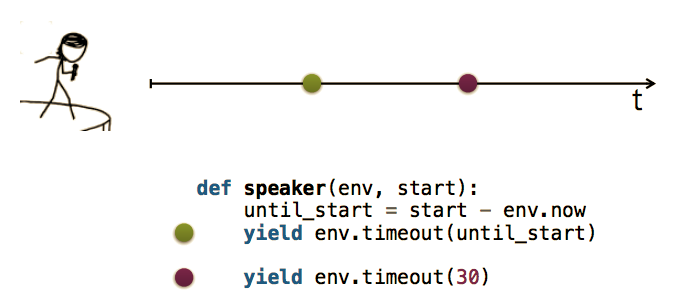

In [35]:
def speaker(env, start):
  print('t: '+str(env.now))
  until_start = start - env.now
  yield env.timeout(until_start)
  print('t: '+str(env.now))
  yield env.timeout(30)
  print('t: '+str(env.now))

env = simpy.Environment()
env.process(speaker(env, 5))
env.run(100)

t: 0
t: 5
t: 35


# Los procesos son eventos, también
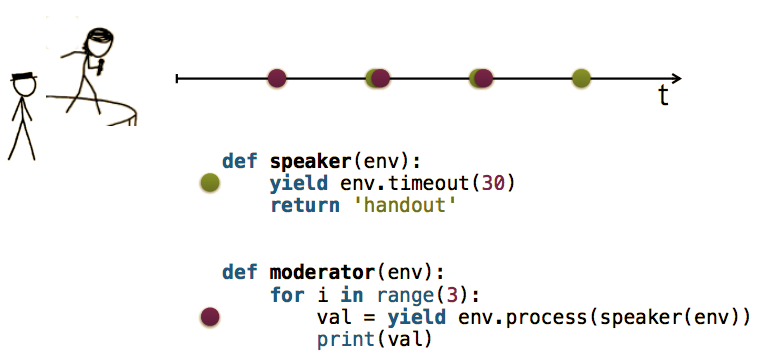

In [31]:
def speaker(env):
  yield env.timeout(30)
  return 'orador: '+ str(env.now) + ' - finaliza charla'

def moderator(env):
  for i in range(5):
    print('moderador: ' + str(env.now))
    val = yield env.process(speaker(env))
    print(val)

env = simpy.Environment()
env.process(moderator(env))
env.run(until=151)

moderador: 0
orador: 30 - finaliza charla
moderador: 30
orador: 60 - finaliza charla
moderador: 60
orador: 90 - finaliza charla
moderador: 90
orador: 120 - finaliza charla
moderador: 120
orador: 150 - finaliza charla


# Interrupciones asincrónicas
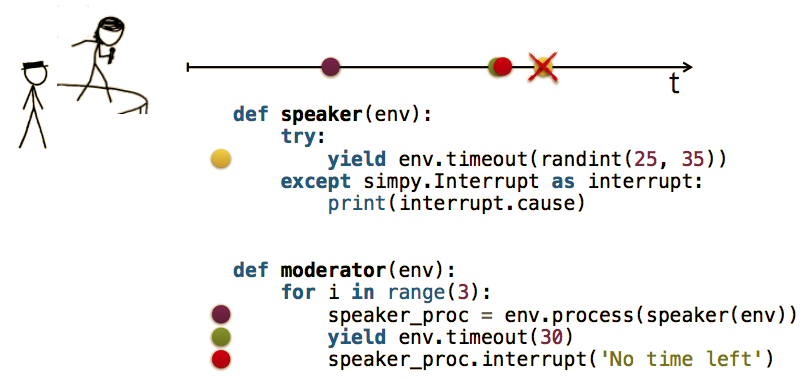

In [33]:
import random as r

def speaker(env):
    try:
        tspeaker = r.randint(25, 35)
        yield env.timeout(tspeaker)
        print('orador: '+ str(env.now) + ' - finaliza charla')
    except simpy.Interrupt as interrupt:
        print(interrupt.cause)

def moderator(env):
    for i in range(3):
        print('moderador: ' + str(env.now))
        speaker_proc = env.process(speaker(env))
        yield env.timeout(30)
        speaker_proc.interrupt('moderador: No queda tiempo.')

env = simpy.Environment()
env.process(moderator(env))
env.run(until=120)

moderador: 0
moderador: 30
moderador: No queda tiempo.
orador: 57 - finaliza charla


RuntimeError: <Process(speaker) object at 0x7b8867139ed0> has terminated and cannot be interrupted.

# Eventos de condición
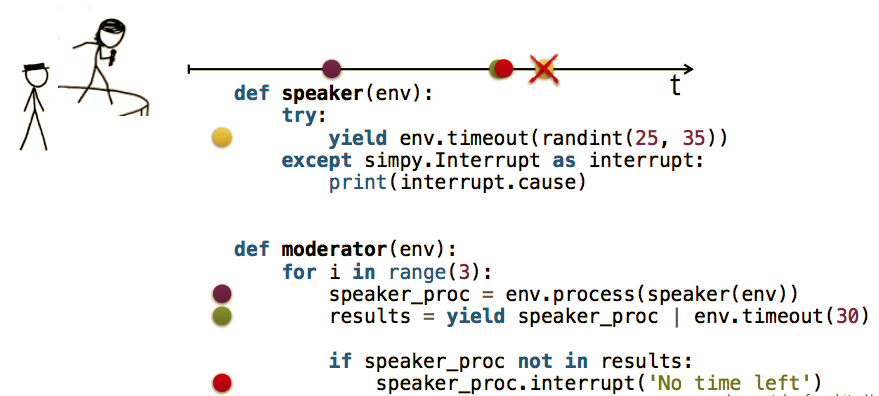

In [36]:
import simpy

def speaker(env):
    try:
        ts = r.randint(25, 35)
        print('orador inicia en: '+str(env.now))
        print('duración de la charla: '+str(ts))
        yield env.timeout(ts)
        print('orador finaliza en: '+str(env.now))
    except simpy.Interrupt as interrupt:
        print(interrupt.cause)

def moderator(env):
    for i in range(10):
        print("El moderador deja que el orador número {} para comenzar a hablar".format(i))
        speaker_proc = env.process(speaker(env))

        print("Tiempo actual: {}".format(env.now))
        time_limit = env.timeout(30)
        print('Tiempo muerto (timeout) creado')
        results = yield speaker_proc | time_limit
        print("El moderador verifica si el orador se pasó del tiempo limite o no")
        print("Límite de tiempo superado: {}".format(speaker_proc not in results))

        if speaker_proc not in results:
            #speaker_proc.interrupt('moderador: No queda tiempo '+str(env.now))

            print("Tiempo actual: {}".format(env.now))
            print(speaker_proc.is_alive)
            speaker_proc.interrupt()
            print("El moderador detiene la charla en: {}".format(env.now))
        print()
        print()

env = simpy.Environment()
env.process(moderator(env))
env.run(until=500)

El moderador deja que el orador número 0 para comenzar a hablar
Tiempo actual: 0
Tiempo muerto (timeout) creado
orador inicia en: 0
duración de la charla: 25
orador finaliza en: 25
El moderador verifica si el orador se pasó del tiempo limite o no
Límite de tiempo superado: False


El moderador deja que el orador número 1 para comenzar a hablar
Tiempo actual: 25
Tiempo muerto (timeout) creado
orador inicia en: 25
duración de la charla: 32
El moderador verifica si el orador se pasó del tiempo limite o no
Límite de tiempo superado: True
Tiempo actual: 55
True
El moderador detiene la charla en: 55


El moderador deja que el orador número 2 para comenzar a hablar
Tiempo actual: 55
Tiempo muerto (timeout) creado
None
orador inicia en: 55
duración de la charla: 31
El moderador verifica si el orador se pasó del tiempo limite o no
Límite de tiempo superado: True
Tiempo actual: 85
True
El moderador detiene la charla en: 85


El moderador deja que el orador número 3 para comenzar a hablar
Tiempo 

# **Ejemplo**: **Asistente a la conferencia**

In [37]:
from random import randint
import simpy

In [38]:
TALKS_PER_SESSION = 3
TALK_LENGTH = 20
BREAK_LENGTH = 15

In [39]:
def attendee(env, name, knowledge=0, hunger=0):
  while True:
    # Visit talks
    for i in range(TALKS_PER_SESSION):
      knowledge += randint(0, 3) / (1 + hunger)
      hunger += randint(1, 4)
      yield env.timeout(TALK_LENGTH)
    print('El asistente %s terminó las charlas con un conocimiento %.2f y hambre '
    '%.2f.' % (name, knowledge, hunger))

    # Go to buffet
    food = randint(3, 12)
    hunger -= min(food, hunger)

    yield env.timeout(BREAK_LENGTH)
    print('El asistente %s terminó de comer con hambre %.2f' % (name, hunger))

In [40]:
env = simpy.Environment()
for i in range(5):
  env.process(attendee(env, i))
env.run(until=220)

El asistente 0 terminó las charlas con un conocimiento 3.00 y hambre 9.00.
El asistente 1 terminó las charlas con un conocimiento 1.00 y hambre 7.00.
El asistente 2 terminó las charlas con un conocimiento 1.87 y hambre 8.00.
El asistente 3 terminó las charlas con un conocimiento 3.50 y hambre 8.00.
El asistente 4 terminó las charlas con un conocimiento 0.83 y hambre 5.00.
El asistente 0 terminó de comer con hambre 0.00
El asistente 1 terminó de comer con hambre 2.00
El asistente 2 terminó de comer con hambre 0.00
El asistente 3 terminó de comer con hambre 0.00
El asistente 4 terminó de comer con hambre 0.00
El asistente 0 terminó las charlas con un conocimiento 6.40 y hambre 12.00.
El asistente 1 terminó las charlas con un conocimiento 2.39 y hambre 11.00.
El asistente 2 terminó las charlas con un conocimiento 4.24 y hambre 9.00.
El asistente 3 terminó las charlas con un conocimiento 5.75 y hambre 9.00.
El asistente 4 terminó las charlas con un conocimiento 4.50 y hambre 8.00.
El asist

# **Ejemplo: Asistente a la conferencia en el buffet**

In [41]:
from random import randint
import simpy

In [59]:
TALKS_PER_SESSION = 4
TALK_LENGTH = 30
BREAK_LENGTH = 5
DURATION_EAT = 2
BUFFET_SLOTS = 3

In [60]:
def attendee(env, name, buffet, knowledge=0, hunger=0):
  while True:
    # Visit talks
    for i in range(TALKS_PER_SESSION):
      knowledge = knowledge + randint(0, 3) / (1 + hunger)
      hunger = hunger + randint(1, 4)
      yield env.timeout(TALK_LENGTH)
    print('El asistente %s terminó las charlas con un conocimiento %.2f y hambre '
    '%.2f.' % (name, knowledge, hunger))

    # Go to buffet
    start = env.now
    with buffet.request() as req:
      yield req | env.timeout(BREAK_LENGTH - DURATION_EAT)
      time_left = BREAK_LENGTH - (env.now - start)

      if req.triggered:
        food = min(randint(3, 12), time_left) # Less time -> less food
        yield env.timeout(DURATION_EAT)
        hunger -= min(food, hunger)
        time_left -= DURATION_EAT
        print('El asistente %s terminó de comer con hambre %.2f' %
              (name, hunger))
      else:
        hunger += 1 # Penalty for only taking a look at all the food.
        print('El asistente %s no llegó al buffet :( , el hambre es ahora '
        'at %.2f.' % (name, hunger))
    yield env.timeout(time_left)

In [62]:
env = simpy.Environment()
buffet = simpy.Resource(env, capacity=BUFFET_SLOTS)
for i in range(7):
  env.process(attendee(env, i, buffet))
env.run(until=320)

El asistente 0 terminó las charlas con un conocimiento 1.68 y hambre 12.00.
El asistente 1 terminó las charlas con un conocimiento 3.33 y hambre 9.00.
El asistente 2 terminó las charlas con un conocimiento 1.12 y hambre 12.00.
El asistente 3 terminó las charlas con un conocimiento 0.93 y hambre 9.00.
El asistente 4 terminó las charlas con un conocimiento 1.13 y hambre 13.00.
El asistente 5 terminó las charlas con un conocimiento 1.49 y hambre 11.00.
El asistente 6 terminó las charlas con un conocimiento 3.50 y hambre 9.00.
El asistente 0 terminó de comer con hambre 7.00
El asistente 1 terminó de comer con hambre 4.00
El asistente 2 terminó de comer con hambre 7.00
El asistente 6 no llegó al buffet :( , el hambre es ahora at 10.00.
El asistente 3 terminó de comer con hambre 6.00
El asistente 4 terminó de comer con hambre 10.00
El asistente 5 terminó de comer con hambre 8.00
El asistente 0 terminó las charlas con un conocimiento 2.80 y hambre 16.00.
El asistente 1 terminó las charlas con